# Part 3: NLP and Sequence Modeling — Mini Project  
### Customer Support Text Classification

This notebook implements a complete NLP pipeline using the provided customer support dataset.  
We will compare traditional vectorization (TF‑IDF) with sequence‑based deep learning (LSTM).

---

## **Tasks Covered**
1. Dataset Understanding  
2. Text Preprocessing  
3. Text Vectorization  
4. Baseline Model (TF‑IDF + Logistic Regression)  
5. Sequence Model (LSTM)  
6. Attention & Transformer Reflection  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


In [ ]:
#Load Dataset

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\customer_support_text_classification.csv")
df.head()


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


# Task 1: Dataset Understanding

Explore below data attributes:
- Number of records  
- Target labels  
- Sample text  
- Average text length  
- Class distribution  


In [6]:
#Dataset Summary
print("Number of records:", len(df))
print("\nTarget labels:", df['sentiment_label'].unique())

df['text_length'] = df['customer_message'].apply(lambda x: len(x.split()))
print("\nAverage text length:", df['text_length'].mean())

print("\nClass distribution:")
print(df['sentiment_label'].value_counts())

df[['customer_message', 'sentiment_label']].head(5)


Number of records: 1500

Target labels: <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Average text length: 12.722666666666667

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


,customer_message,sentiment_label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral


# Task 2: Text Preprocessing

Steps:
- Lowercasing  
- Removing symbols  
- Tokenization  
- Stopword removal  
- Padding (for LSTM model)  


In [12]:
#Preprocessing Function
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

df['clean_text'] = df['customer_message'].apply(clean_text)
df[['customer_message', 'clean_text']].head()


,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund pending experience frustrating ticket n...
4,Please tell me how to update my account details.,tell update account details


# Task 3: Text Vectorization

We compare:
- TF‑IDF (traditional)
- Tokenizer + padded sequences (for LSTM)

**Why vectorization?**  
Models cannot understand raw text.  
Vectorization converts words → numbers → model‑readable format.


In [13]:
#TF‑IDF Vectorization
X = df['clean_text']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


# Task 4: Baseline Model  
### Logistic Regression + TF‑IDF


In [14]:
#Baseline Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



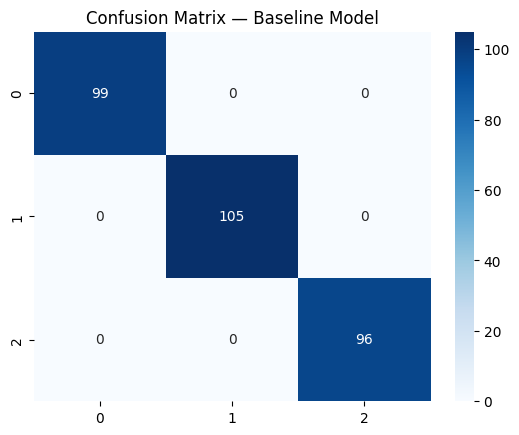

In [15]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix — Baseline Model")
plt.show()


# Task 5: Sequence Model (LSTM)

Architecture:
- Tokenizer → sequences  
- Embedding layer  
- LSTM layer  
- Dense output  
- Loss: categorical crossentropy  
- Metric: accuracy  


In [16]:
#Tokenizer + Padding
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

X_seq = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(X_seq, maxlen=30, padding='post')

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

label_map = {'negative':0, 'neutral':1, 'positive':2}
y_train_s = y_train_s.map(label_map)
y_test_s = y_test_s.map(label_map)


In [ ]:
#LSTM Model
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=30),
    LSTM(64),
    Dense(3, activation='softmax')
])

# Build the model
model_lstm.build(input_shape=(None, 30))

# Compile AFTER building
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,219 (1.35 MB)

 Trainable params: 353,219 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Train LSTM
history = model_lstm.fit(
    X_train_s, y_train_s,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)


Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3396 - loss: 1.0996 - val_accuracy: 0.3042 - val_loss: 1.0997
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6198 - loss: 0.7958 - val_accuracy: 0.6417 - val_loss: 0.4776
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6771 - loss: 0.4582 - val_accuracy: 0.6417 - val_loss: 0.4623
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6687 - loss: 0.4602 - val_accuracy: 0.6417 - val_loss: 0.4935
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.4528 - val_accuracy: 0.6417 - val_loss: 0.4751


In [22]:
#Evaluate LSTM
loss, acc = model_lstm.evaluate(X_test_s, y_test_s)
print("LSTM Accuracy:", acc)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6800 - loss: 0.4572 
LSTM Accuracy: 0.6800000071525574


# Task 6: Attention & Transformer Reflection

### Why RNNs struggle with long-term dependencies  
RNNs pass information step‑by‑step, causing earlier information to fade (vanishing gradients).

### How LSTMs help  
LSTMs add gates (input, forget, output) that allow them to store and protect important information.

### What attention solves  
Attention lets the model focus on the most relevant words in the input, regardless of position.

### Why transformers matter  
Transformers use self‑attention to process all words in parallel, enabling:
- Better long‑range understanding  
- Faster training  
- Foundation models like GPT, BERT, T5  


In [23]:
df_results = pd.DataFrame({
    "true": y_test,
    "predicted": y_pred
})
df_results.to_csv("results/sample_predictions.txt", index=False)

print("Results saved.")


Results saved.
